# 1. Dataset Overview

This project uses the [Food-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) from the paper [Food 101 - Mining Discriminative Components with Random Forests](https://link.springer.com/chapter/10.1007/978-3-319-10599-4_29) Lukas Bossard, Matthieu Guillaumin and Luc Van Gool published in the Computer Vision -- ECCV 2014 conference paper.

This dataset contains 101 food categories with 1,000 images each for a total of 101,000 images. 
- The dataset is officially split by 750 training and 250 test images per class.
- The test images are manually reviewed (**clean**)
- The training images are not manually reviewed (**unclean**) with wrong labels, bad crops, and certain photos contaning several dishes.
- I'm pretty sure I also saw a baby labeled as "chicken curry" so there are a lot of challenges for any potential CNN to overcome.


## 1.1 Load dataset and print basic info

In [1]:
%load_ext autoreload
%autoreload 2

# import libraries + functions & classes from train
import torch, random
from torch.utils.data import DataLoader, Subset
from pathlib import Path
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

from train import (CompactImageFolder, load_official_split,
                            download_food_dataset, pre_resize_dataset)

MEAN, STD = [0.5576, 0.4423, 0.327], [0.2591, 0.263, 0.2656]

In [4]:
# return immediately if dataset already on disk
download_food_dataset()
PATH = pre_resize_dataset()

# Caches the scanned file list so kernel restarts don't rewalk 101k files.
# Path.home() keeps this working on both machines
CACHE = str(Path.home() / "Documents" / "ml-runs")

dataset = CompactImageFolder(root=PATH, transform=transforms.ToTensor(), cache_dir=CACHE)
tr_idx, va_idx, te_idx = load_official_split(dataset, PATH)

dataset found
scaled dataset found
train 68175 | val 7575 | test 25250


The below cell simply saves `classes.json` again. Since it's already part of the repo, you don't have to run it.

In [ ]:
import json
from pathlib import Path

out = Path.cwd().parent / "classes.json"
with open(out, "w") as f:
    json.dump(dataset.classes, f, indent=2)
print(f"wrote {len(dataset.classes)} classes to {out}")

In [5]:
# Verify the split rather than trusting it -- if these counts are wrong,
# load_official_split has a bug and every number downstream is meaningless.
counts = np.bincount(dataset.targets)

print(f"classes      : {len(dataset.classes)}")
print(f"total images : {len(dataset):,}")
print(f"per class    : min {counts.min()}, max {counts.max()}")
print(f"train        : {len(tr_idx):,}")
print(f"val          : {len(va_idx):,}    (10% of noisy training data carved out)")
print(f"test         : {len(te_idx):,}   (official, manually reviewed)")
print(f"\nfirst 8 classes: {', '.join(dataset.classes[:8])}")

classes      : 101
total images : 101,000
per class    : min 1000, max 1000
train        : 68,175
val          : 7,575    (10% of noisy training data carved out)
test         : 25,250   (official, manually reviewed)

first 8 classes: apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare, beet_salad, beignets, bibimbap


## 1.2 Measure Mean/STD for Normalization (do not run unless needed)

In [ ]:
# run once to produce the MEAN/STD
stat_tfm = transforms.Compose([transforms.Resize(256),
                               transforms.CenterCrop(224),
                               transforms.ToTensor()])
raw = CompactImageFolder(root=path, transform=stat_tfm)


stat_loader = DataLoader(Subset(raw, tr_idx), batch_size=256, num_workers=0)
channel_sum, channel_sq_sum, count = torch.zeros(3), torch.zeros(3), 0
for images, _ in stat_loader:
    b = images.shape[0]
    pixels = images.view(b, 3, -1)          # (b,3,H,W) -> (b,3,H*W)
    channel_sum    += pixels.mean(2).sum(0)
    channel_sq_sum += (pixels ** 2).mean(2).sum(0)
    count          += b
mean = channel_sum / count
std  = (channel_sq_sum / count - mean ** 2).sqrt()   # sqrt(E[x^2] - E[x]^2)
print("MEAN =", [round(v, 4) for v in mean.tolist()])
print("STD  =", [round(v, 4) for v in std.tolist()])

MEAN = [0.5576, 0.4423, 0.327]
STD  = [0.2591, 0.263, 0.2656]


## 1.3 Display subset of batch

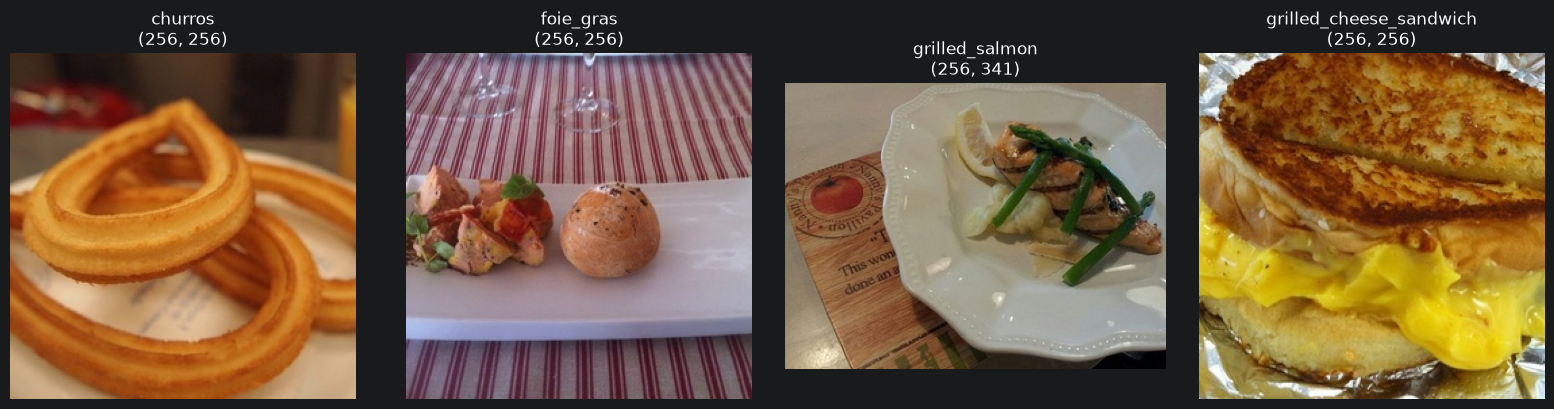

In [6]:
# pick indices of 4 random images
picks = random.sample(range(len(dataset)), 4)

fig, ax = plt.subplots(ncols=4, figsize=(16, 4))
for a, i in zip(ax, picks):
    img, label = dataset[i]                 
    a.imshow(img.permute(1, 2, 0))          # (C,H,W) -> (H,W,C) for matplotlib
    a.set_title(f"{dataset.classes[label]}\n{tuple(img.shape[1:])}")
    a.axis("off")
plt.tight_layout()

## 1.4 Augmentation Preview

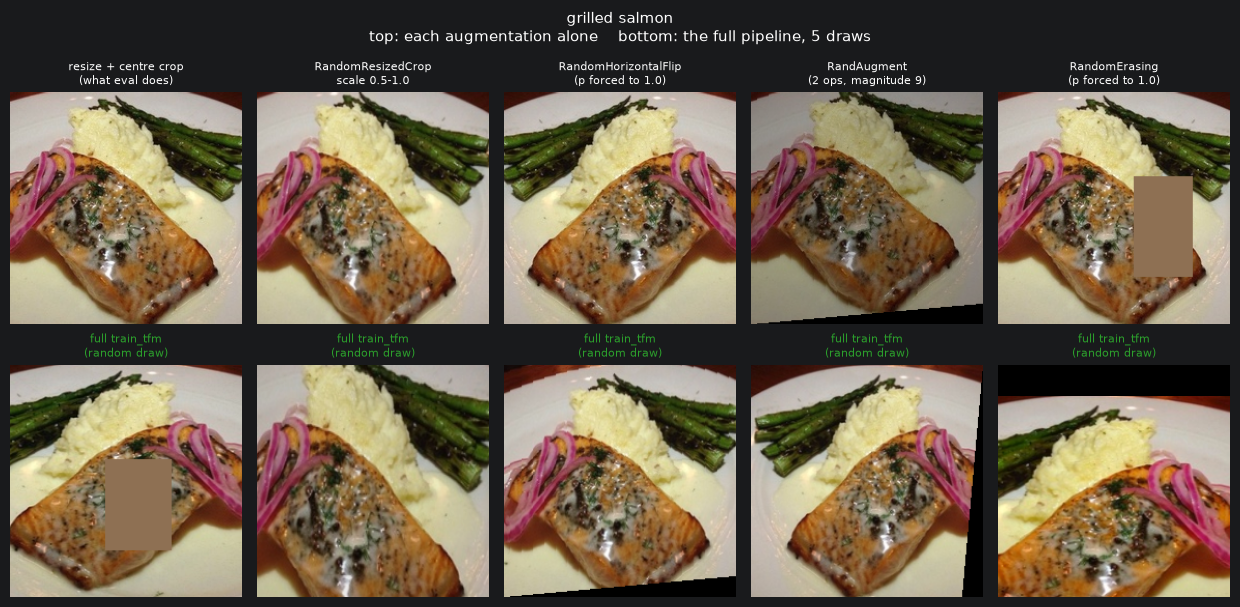

In [9]:
from train import build_transforms
from PIL import Image
import torchvision.transforms as T

train_tfm, eval_tfm = build_transforms(MEAN, STD)
mean_t, std_t = torch.tensor(MEAN).view(3,1,1), torch.tensor(STD).view(3,1,1)
to_tensor = T.Compose([T.ToTensor(), T.Normalize(MEAN, STD)])
unnorm = lambda x: (x * std_t + mean_t).clip(0, 1).permute(1, 2, 0)   # undo Normalize for display

i = random.Random(0).randrange(len(dataset))
t = int(dataset.targets[i])
src = Path(PATH) / dataset.classes[t] / dataset.fnames[i].decode()
base = Image.open(src).convert("RGB")

# TOP ROW: each augmentation on its own, so the panel titles mean something.
# train_tfm is a single Compose containing all of them, so showing it repeatedly
# only varies the random draw -- it can't tell you what each piece does.
#
# flip and erasing have their probability forced to 1 here: at their real p
# (0.5 and 0.25) most panels would show no visible effect at all.
stages = [
    ("resize + centre crop\n(what eval does)",
     T.Compose([T.Resize(256), T.CenterCrop(224), to_tensor])),
    ("RandomResizedCrop\nscale 0.5-1.0",
     T.Compose([T.RandomResizedCrop(224, scale=(0.5, 1.0)), to_tensor])),
    ("RandomHorizontalFlip\n(p forced to 1.0)",
     T.Compose([T.Resize(256), T.CenterCrop(224), T.RandomHorizontalFlip(p=1.0), to_tensor])),
    ("RandAugment\n(2 ops, magnitude 9)",
     T.Compose([T.Resize(256), T.CenterCrop(224), T.RandAugment(num_ops=2, magnitude=9), to_tensor])),
    ("RandomErasing\n(p forced to 1.0)",
     T.Compose([T.Resize(256), T.CenterCrop(224), to_tensor, T.RandomErasing(p=1.0)])),
]

cols = len(stages)                      # 5 across, 2 down
fig, ax = plt.subplots(2, cols, figsize=(2.5 * cols, 6.4))

for a, (name, tf) in zip(ax[0], stages):
    a.imshow(unnorm(tf(base)))
    a.set_title(name, fontsize=8)

# BOTTOM ROW: the real pipeline, one draw per panel. same transform every time --
# only the randomness differs, which is what the model actually sees each epoch.
for a in ax[1]:
    a.imshow(unnorm(train_tfm(base)))
    a.set_title("full train_tfm\n(random draw)", fontsize=8, color="tab:green")

for a in ax.ravel():
    a.axis("off")

fig.suptitle(f"{dataset.classes[t].replace('_', ' ')}\n"
             f"top: each augmentation alone    bottom: the full pipeline, 5 draws",
             fontsize=11)
plt.tight_layout()


# 2. Training

Training occurs in `train.py`.

I learned the hard way when I migrated from my Macbook to my Windows PC (to take advantage of my Desktop GPU) that parallel data-loading was a headache on Windows.

Loading data in parallel (for speed) requires helper processes. While Unix systems can copy an existing process, Windows can't, so it has to start up an empty process and rebuild using the setup code. For a notebook, its classes live only in the kernel's memory, so there is no source file for a worker to re-import. The workers then die during startup, causing the main process to wait. This makes the training hang forever.

To alleviate this, each new process needs a guard in the setup code that tells it which specific parts are meant to be re-run. Notebooks have no place to put that guard, so setting `num_workers` above 0 on Windows causes the hang. `.py` scripts have this guard in the form of the `if __name__ == "__main__":` block, which only runs in the main process and in none of the helpers.

# 3. Explore Results

## 3.1 Test-Time Augmentation accuracy boost on model

Now with our model fully trained, let's import it and run it through Test-Time Augmentation to boost its accuracy. This cell takes a while, so don't re-run unless needed!

In [15]:
# 3.1 - reproduce the headline number
from tta import choose_device, load_model, evaluate, load_test_split

device = choose_device()
te_idx = load_test_split(dataset, PATH)
scales = [(256, 224), (288, 256), (320, 288)]
CKPT = '../deepcnn_food101.pt'
model = load_model(CKPT, len(dataset.classes), device)

# 25,250 images x 6 passes is expensive so try to avoid a rerun if possible.
probs, labels = evaluate(model, dataset, te_idx, scales, device, num_workers=8)

acc = 100 * (probs.argmax(1) == labels).float().mean().item()
print(f"\nfull TTA top-1: {acc:.2f}%   over {len(labels):,} test images")

  256/224  + flip : 82.82%
  288/256  + flip : 84.21%
  320/288  + flip : 83.70%

full TTA top-1: 84.37%   over 25,250 test images


Using TTA is able to bump our accuracy to almost 85%. This same technique is used in `predict.py` to get us the best results possible.

## 3.2 Test out model

Let's use a sample image from the internet and test our model before we go further. I've pulled a picture of a Paella taken from reddit.


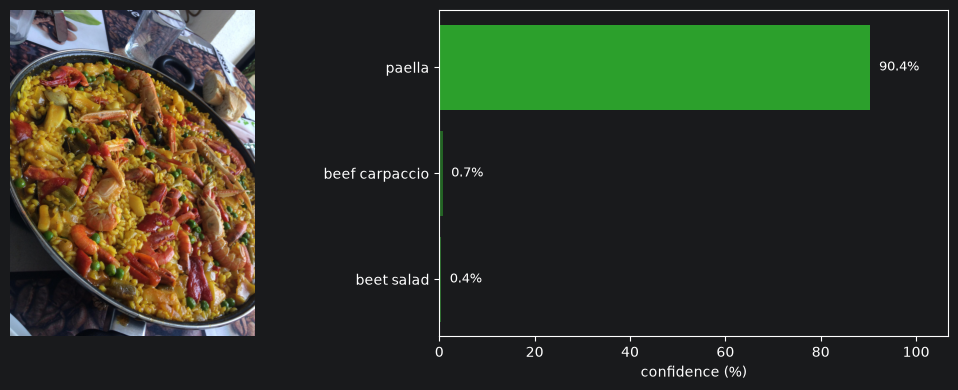

In [31]:
import matplotlib.pyplot as plt
from predict import FoodClassifier, open_image, read_source

clf = FoodClassifier("../deepcnn_food101.onnx", "../classes.json")
img = open_image(read_source("https://i.redd.it/k2m13b5sg1lz.jpg"))
preds = clf.classify(img, topk=3)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img); ax[0].axis("off")
names = [n.replace('_', ' ') for n, _ in preds][::-1]
vals  = [c * 100 for _, c in preds][::-1]
bars = ax[1].barh(names, vals, color="tab:green", alpha=.55)
bars[-1].set_alpha(1.0)
ax[1].set_xlim(0, max(vals) * 1.18)
ax[1].set_xlabel("confidence (%)")
for b, v in zip(bars, vals):
    ax[1].text(v + max(vals) * 0.02, b.get_y() + b.get_height() / 2,
               f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()

Note that the photo is tilted and slightly zoomed in. Despite that, the model can still guess it's a Paella with relatively high confidence.

## 3.3 Per-class accuracy

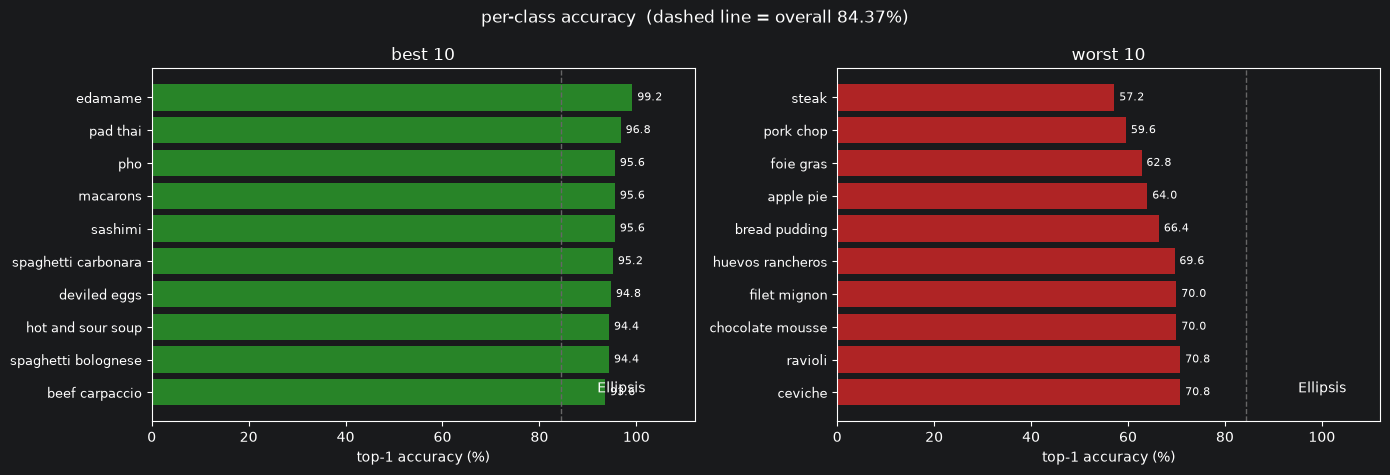

In [32]:
import numpy as np

pred = probs.argmax(1)
classes = np.array(dataset.classes)
overall = 100 * (pred == labels).float().mean().item()

# Food-101's test split is exactly 250 images per class, so every denominator is
# the same. per-class accuracy is directly comparable, and the mean of the
# per-class scores equals the overall score
per_class = np.array([(pred[labels == c] == c).float().mean().item()
                      for c in range(len(classes))])
counts = np.array([(labels == c).sum().item() for c in range(len(classes))])
assert len(set(counts)) == 1, f"unbalanced test split: {sorted(set(counts))}"

order = per_class.argsort()
worst, best = order[:10], order[-10:][::-1]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for a, idx, title, colour in [(ax[0], best,  "best 10",  "tab:green"),
                              (ax[1], worst, "worst 10", "tab:red")]:
    a.barh(range(len(idx)), per_class[idx] * 100, color=colour, alpha=.8)
    a.set_yticks(range(len(idx)))
    a.set_yticklabels([classes[i].replace('_', ' ') for i in idx], fontsize=9)
    a.invert_yaxis()
    a.set_xlim(0, 112)                    # headroom past 100 for the labels
    a.set_xticks([0,20,40,60,80,100])     # only tick to 100
    a.text(v + 1.5, j, ...)               # nudged slightly further out
    a.set_xlabel("top-1 accuracy (%)")
    a.set_title(title)
    a.axvline(overall, ls="--", c="0.4", lw=1)
    for j, v in enumerate(per_class[idx] * 100):
        a.text(v + 1, j, f"{v:.1f}", va="center", fontsize=8)

fig.suptitle(f"per-class accuracy  (dashed line = overall {overall:.2f}%)")
plt.tight_layout()

We can see that the most visually distinct dishes in our model's eyes are things like edamame, pad thai, and pho. All very visually distinctive. On the other hand, steak, pork chop, and foie gras seem to perform the worst. This can partially be attributed to their visual similarity which may confuse the model. We can explore this further by seeing which pairs are mixed up the most.

## 3.4 Most popular mixups

In [18]:
from collections import defaultdict

pred  = probs.argmax(1)
wrong = pred != labels
per_class_n = 250 # Food-101 test split

pairs = torch.stack([labels[wrong], pred[wrong]], dim=1)
uniq, counts = pairs.unique(dim=0, return_counts=True)
order = counts.argsort(descending=True)

# so we can look up the opposite direction of each pair
lookup = defaultdict(int)
for (t, p), c in zip(uniq.tolist(), counts.tolist()):
    lookup[(t, p)] = c

print(f"{int(wrong.sum()):,} errors over {len(labels):,} images\n")
print(f"{'true':<24}{'guessed as':<24}{'n':>4}{'% of class':>12}{'reverse':>9}")
print("-" * 73)
for k in order[:15].tolist():
    t, p = uniq[k].tolist()
    n = int(counts[k])
    print(f"{dataset.classes[t].replace('_',' '):<24}"
          f"{dataset.classes[p].replace('_',' '):<24}"
          f"{n:>4}{100*n/per_class_n:>11.1f}%{lookup[(p, t)]:>9}")

3,947 errors over 25,250 images

true                    guessed as                 n  % of class  reverse
-------------------------------------------------------------------------
filet mignon            steak                     38       15.2%       37
steak                   filet mignon              37       14.8%       38
chocolate cake          chocolate mousse          28       11.2%       28
chocolate mousse        chocolate cake            28       11.2%       28
pork chop               filet mignon              24        9.6%        5
prime rib               steak                     24        9.6%       20
steak                   prime rib                 20        8.0%       24
pork chop               steak                     17        6.8%       13
club sandwich           grilled cheese sandwich   17        6.8%       12
tuna tartare            beef tartare              16        6.4%       13
grilled salmon          pork chop                 16        6.4%       12
falaf

Our guess about filet mignon and steak was correct. The model struggles on certain dishes that look very close to eachother. Now let's take a look at guesses the model was confidently incorrect on.

## 3.5 Failure Gallery

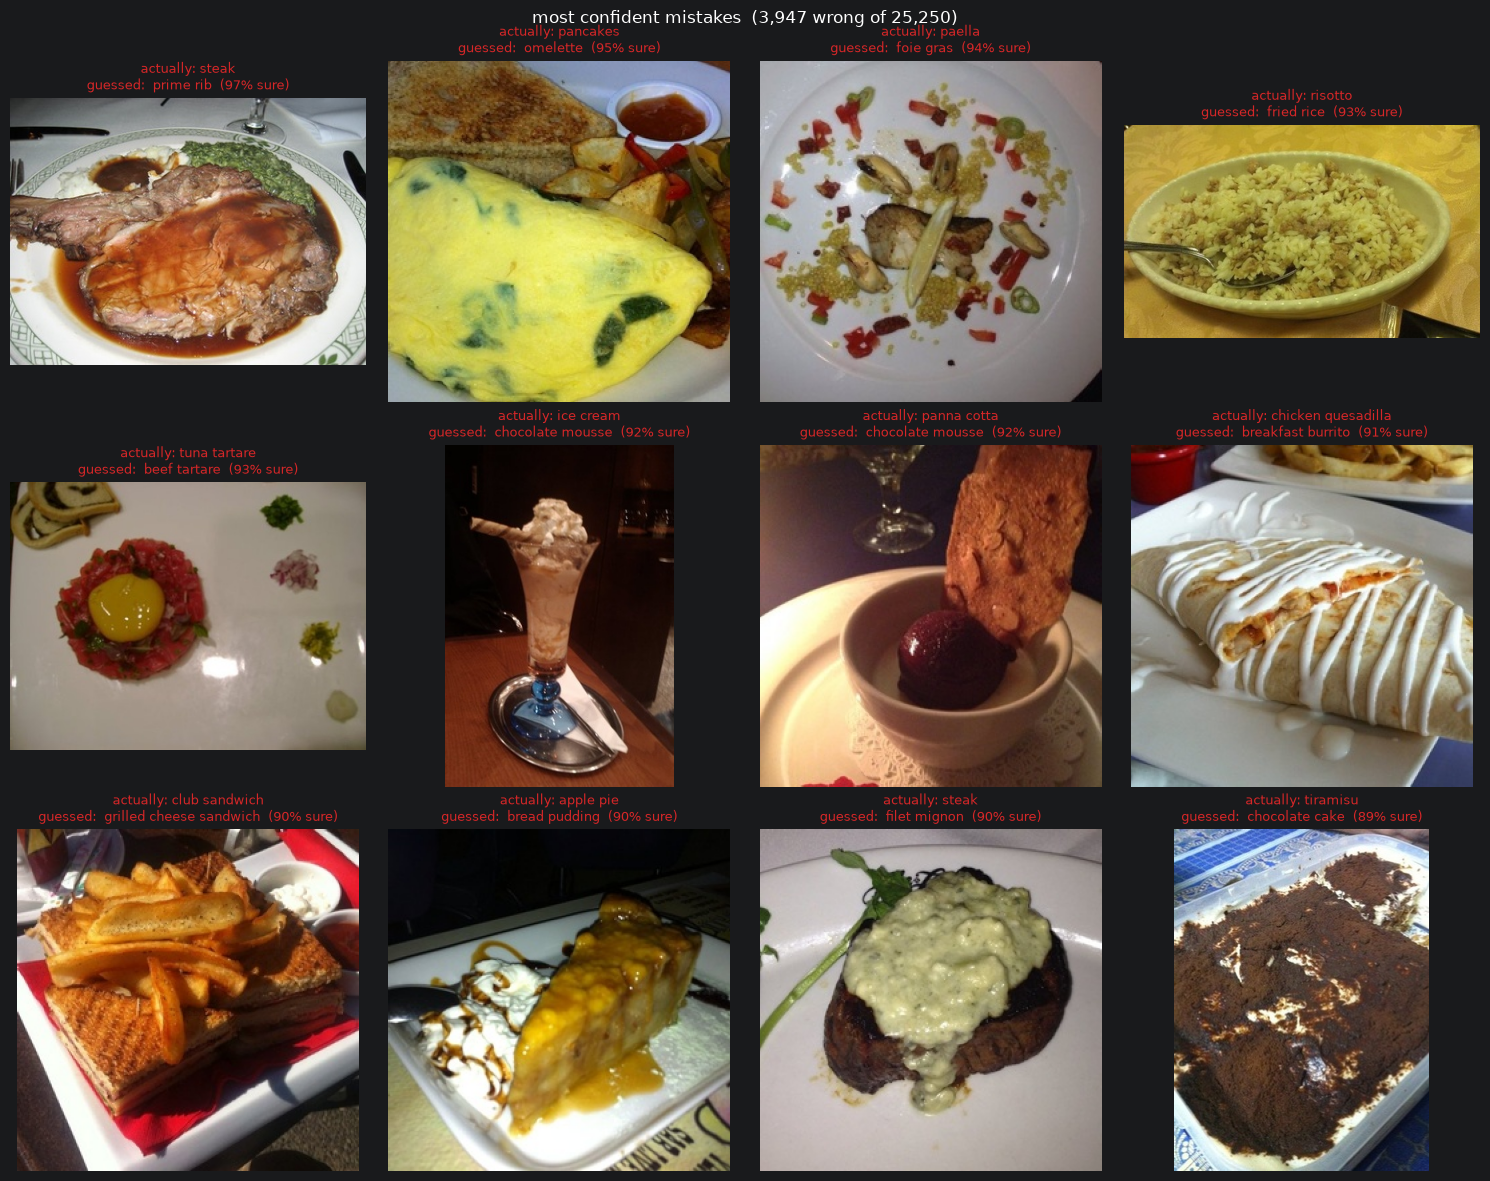

In [33]:
from PIL import Image

pred = probs.argmax(1)
conf = probs.max(1).values
wrong = (pred != labels).nonzero().squeeze(1)

# what was the model confidently incorrect about
show = wrong[conf[wrong].argsort(descending=True)][:12]

rows, cols = 3, 4
fig, ax = plt.subplots(rows, cols, figsize=(15, 12))
for a, i in zip(ax.ravel(), show.tolist()):
    ds_i = int(te_idx[i]) # row i of probs  ->  dataset index te_idx[i]
    t = int(dataset.targets[ds_i])
    src = Path(PATH) / dataset.classes[t] / dataset.fnames[ds_i].decode()
    a.imshow(Image.open(src).convert("RGB"))
    a.set_title(f"actually: {dataset.classes[int(labels[i])].replace('_', ' ')}\n"
                f"guessed:  {dataset.classes[int(pred[i])].replace('_', ' ')}"
                f"  ({conf[i] * 100:.0f}% sure)",
                fontsize=9, color="tab:red")
    a.axis("off")
for a in ax.ravel()[len(show):]:
    a.axis("off")

fig.suptitle(f"most confident mistakes  ({len(wrong):,} wrong of {len(labels):,})", fontsize=12)
plt.tight_layout()

## 3.6 - Is the confidence number meaningful?

mean confidence 60.6%  vs  accuracy 84.4%


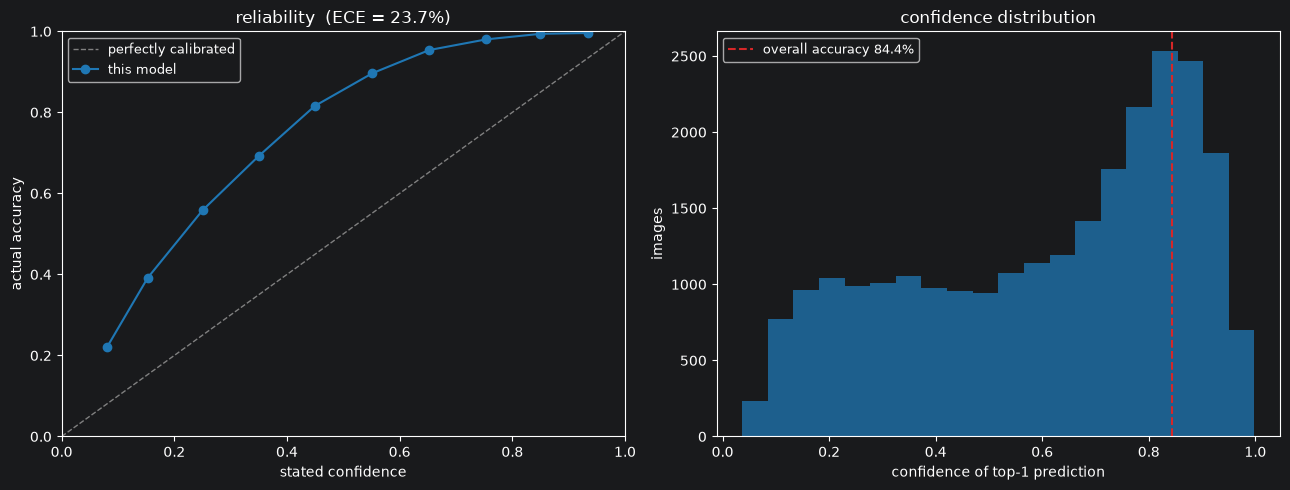

In [37]:
pred    = probs.argmax(1)
conf    = probs.max(1).values
correct = (pred == labels).float()
N       = len(labels)

edges = torch.linspace(0, 1, 11)
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (conf > lo) & (conf <= hi)
    if m.sum() == 0:
        continue
    rows.append((lo.item(), hi.item(), int(m.sum()),
                 conf[m].mean().item(), correct[m].mean().item()))

# Expected Calibration Error: average gap between stated confidence and actual
# accuracy, weighted by how many predictions land in each bin.
ece = sum(n / N * abs(a - c) for _, _, n, c, a in rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# reliability diagram -- perfect calibration is the diagonal
ax[0].plot([0, 1], [0, 1], "--", c="0.5", lw=1, label="perfectly calibrated")
ax[0].plot([c for *_, c, _ in rows], [a for *_, a in rows],
           "o-", color="tab:blue", label="this model")
ax[0].set_xlabel("stated confidence"); ax[0].set_ylabel("actual accuracy")
ax[0].set_xlim(0, 1); ax[0].set_ylim(0, 1)
ax[0].set_title(f"reliability  (ECE = {100*ece:.1f}%)")
ax[0].legend(fontsize=9)

# where predictions actually fall -- the diagram above is meaningless in bins
# that hold almost no predictions
ax[1].hist(conf.numpy(), bins=20, color="tab:blue", alpha=.75)
ax[1].axvline(correct.mean().item(), ls="--", c="tab:red",
              label=f"overall accuracy {100*correct.mean():.1f}%")
ax[1].set_xlabel("confidence of top-1 prediction"); ax[1].set_ylabel("images")
ax[1].set_title("confidence distribution"); ax[1].legend(fontsize=9)

plt.tight_layout()
print(f"mean confidence {100*conf.mean():.1f}%  vs  accuracy {100*correct.mean():.1f}%")

The model appears to be fairly unconfident in its results, giving conservative prediction scores when in reality it may be more accurate than it lets on. This is a consequence of label smoothing and the TTA code softening its decision-making.

# 4. Conclusion

We've successfully loaded the dataset, taken a peek under the hood of how images are augmented to boost model accuracy, tested the model ourselves, and seen where it performs the best and worst. [Check out the live model](https://image-cnn.vercel.app/) and try it for yourself now!